In [1]:
import time
start_time_script = time.time()

import xarray as xr
import dask.array as da
import numpy as np

from netCDF4 import Dataset
from datetime import date, datetime

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pandas as pd
import math

import geopandas as gpd
import regionmask

/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Options

In [2]:
print("OPTIONS") 

pathdata="DATA"
pathoutputfig="PLOT"

# input data
model='oisst' #oisst cmems 
yearbeg=1981
yearend=2025  #2024
region='Portugal_200m_bathymetry' #Portugal 200m bathymetry from shapefile
choice_mask_region=0 #-1=no mask 4=Med
choice_date=0 #0=no, 1=yes (choose start_date and end_date)
start_mth=1 #3 #6 #3                                        #CHANGED
start_day=1 #28 #1 #28                                      #CHANGED 
end_mth=12 #9 #4 #8 #4                                      #CHANGED
end_day=31 #30 #14 #31 #14                                  #CHANGED
print("choice_mask_region",choice_mask_region)

#import_data
import_data = 'y'

#Calculation
mhw_calculation = 'y'
detrend=0 #0/1
clim_start_year = 1982
clim_end_year   = 2024
percentile = 0.9
min_duration_mhw=5
min_gap_mhw=2 
dt_clim='time.dayofyear' #'time.dayofyear'  # 'time.month'
dt='day'

print("OPTIONS/PLOT")
plot = 'y'
size_fonte=14 
format_fig='png'
dpi_value=150   

OPTIONS
choice_mask_region 0
OPTIONS/PLOT


# Import Data


TIME IMPORT DATA - START 0.021181519826253256
type(var) <class 'xarray.core.dataarray.DataArray'>
sst.shape (16190, 48, 30)
sst.dims ('time', 'lat', 'lon')
<xarray.Dataset> Size: 8MB
Dimensions:    (lat: 720, lon: 1440)
Coordinates:
  * lat        (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon        (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    cell_area  (lat, lon) float64 8MB ...
Attributes:
    CDI:          Climate Data Interface version 2.6.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Sun Mar 01 17:42:22 2026: cdo gridarea /Users/miguelsilveir...
    CDO:          Climate Data Operators version 2.6.0 (https://mpimet.mpg.de...


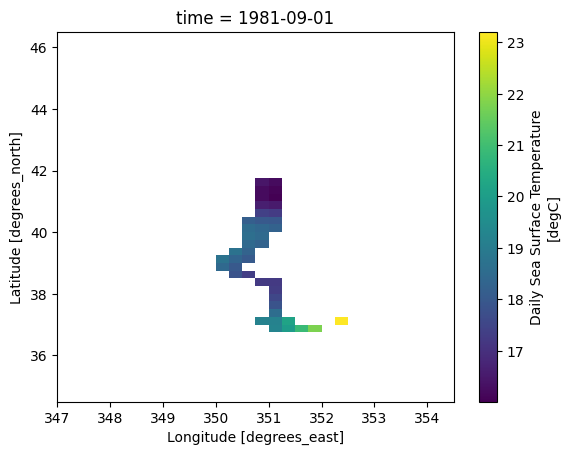

In [3]:
################   
# IMPORT DATA  #
################
if import_data == 'y':
   print("TIME IMPORT DATA - START", (time.time() - start_time_script)/60)

   ds = xr.open_dataset(r"/Users/miguelsilveira/Documents/TeseFilesPython/marine-extreme-event-main/sst_merged_big_box_IbPen.nc", engine='netcdf4')  #0928 
   sst = ds.sst
   print("type(var)", type(sst))
   print("sst.shape",sst.shape)
   print("sst.dims",sst.dims)
   ds_grid=xr.open_dataset(f'/Users/miguelsilveira/Documents/TeseFilesPython/marine-extreme-event-main/gridarea.nc', engine='netcdf4')
   print(ds_grid)
   cell_area = ds_grid.cell_area

   if choice_mask_region > 0:
      mask_region = np.load(f'{pathdata}/OceanMasks_oisst_{region}.npy')
      if model != 'oisst':
         mask_interp = xr.DataArray(mask_region,
                           dims=('lat', 'lon'),
                           coords={'lat': ds['lat'].values, 'lon': ds['lon'].values})
         mask_region = mask_interp.interp(lat=ds.lat, lon=ds.lon, method='nearest')
      print("mask_region",mask_region)
      print("np.shape(mask_region)",np.shape(mask_region))      
      sst = sst.where(mask_region == choice_mask_region)

   from shapely.ops import unary_union

   # Load shapefile
   shp_path = "200m"   # ← change this
   gdf = gpd.read_file(shp_path)

   # Reproject to WGS84 if needed
   if gdf.crs and gdf.crs.to_epsg() != 4326:
      gdf = gdf.to_crs(epsg=4326)

   # Merge all polygons into one
   merged_geom = unary_union(gdf.geometry)
   gdf_single = gpd.GeoDataFrame(
      {"region_name": ["myregion"], "geometry": [merged_geom]},
      crs=gdf.crs
   )

   # Build mask and apply
   regions = regionmask.from_geopandas(gdf_single, names="region_name")
   shp_mask = regions.mask(sst.lon, sst.lat)
   sst = sst.where(shp_mask >= 0)

   
   sst.isel(time=0).plot()
   plt.show()
   
   

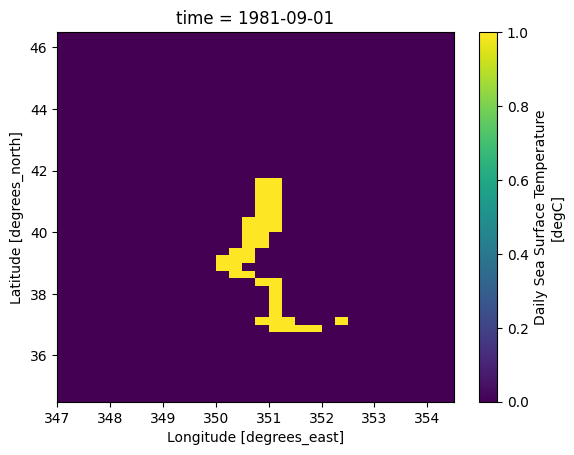

In [4]:
mask_ocean = 1 * np.ones(sst.shape[1:]) * np.isfinite(sst.isel(time=0))
mask_land  = 0 * np.ones(sst.shape[1:]) * np.isnan(sst.isel(time=0))

mask = mask_ocean + mask_land
mask.plot()
plt.show()

if choice_date == 1: # 
    print("choice_date") 
    if start_mth <= end_mth:
        # Case 1: Normal range (e.g., June 15 - September 30)
        mask_date = ((sst['time.month'] > start_mth) & (sst['time.month'] < end_mth)) | \
                ((sst['time.month'] == start_mth) & (sst['time.day'] >= start_day)) | \
                ((sst['time.month'] == end_mth) & (sst['time.day'] <= end_day))  
    else:
        # Case 2: Wrapping around the new year (e.g., December 10 - March 15)
        mask_date = ((sst['time.month'] > start_mth) | (sst['time.month'] < end_mth)) | \
                ((sst['time.month'] == start_mth) & (sst['time.day'] >= start_day)) | \
                ((sst['time.month'] == end_mth) & (sst['time.day'] <= end_day))
    filtered_values = sst[mask_date]
    # Select data using the mask
    sst = sst.sel(time=mask_date)

# MHW Calculation

In [5]:
print("TIME MHW_CALCULATION - START", (time.time() - start_time_script)/60)
print("np.shape(sst)",np.shape(sst))

TIME MHW_CALCULATION - START 0.03593984842300415
np.shape(sst) (16190, 48, 30)


### Detrending


In [6]:

##############
# Detrending
##############

if detrend == 1:
    time_axis = np.arange(len(sst['time']))
    print("time", time_axis)
    # Initialize an array to store the detrended SST data
    sst_detrended = np.zeros_like(sst)  # Same shape as sst

    # Reshape sst to a 2D array where each column is a time series for a (lat, lon) point
    sst_reshaped = sst.values.reshape(sst.sizes['time'], -1)
    # Perform regression on each time series
    trends = np.polyfit(time_axis, sst_reshaped, detrend)
    # Calculate the trend lines for each time series
    trend_lines = trends[0, :] * time_axis[:, np.newaxis] + trends[1, :]
    # Reshape trend_lines back to the original shape
    trend_lines_reshaped = trend_lines.reshape(sst.sizes['time'], sst.sizes['lat'], sst.sizes['lon'])

    # Subtract the trend from the original sst array
    sst_detrended = sst.values - trend_lines_reshaped
    sst = xr.DataArray(
    sst_detrended,
    dims=sst.dims,
    coords=sst.coords,
    attrs=sst.attrs,
    name=sst.name
    )
    
    #sst.rename("sst_detrended").to_netcdf(f"{pathdata}/OUTPUT/sst.detrend{detrend}_{model}.{yearbeg}{yearend}.{region}.start{start_day}-{start_mth}to{end_day}-{end_mth}.{region}.nc")  
    

In [7]:
# Threshold
sst_clim_period = sst.sel(time=slice(f"{clim_start_year}-01-01", f"{clim_end_year}-12-31"))
climatology = sst_clim_period.groupby(dt_clim).mean().rolling(dayofyear=11, center=True, min_periods=1).mean()
sstanomalyclim = sst.groupby(dt_clim) - climatology
#sstanomalyclim.rename("sst_deseasonalized").to_netcdf(f"{pathdata}/OUTPUT/sst.detrend{detrend}.deseasonalized1_{model}.{yearbeg}{yearend}.{region}.start{start_day}-{start_mth}to{end_day}-{end_mth}.{region}.nc")  
threshold = sst.groupby(dt_clim).quantile(percentile, dim='time', keep_attrs=True, skipna=True)
mhw_meanintensity_all = sstanomalyclim.groupby(dt_clim).where(sst.groupby(dt_clim)>threshold)
print("TIME MHW_CALCULATION - AFTER THRESHOLD", (time.time() - start_time_script)/60)
del climatology, threshold

##############
# min_duration & min_gap
def filter_short_sequences(da, min_duration=min_duration_mhw-1, min_gap=min_gap_mhw):
    filtered_da = da.copy()
    # Iterate over each grid cell
    for i in range(da.sizes['lat']): #range(13,14): ##: 
        for j in range(da.sizes['lon']): #range(16,17): #range(da.sizes['lon']):  #range(da.sizes['lon']):
            # Extract the time series for the current grid cell
            ts = da.isel(lat=i, lon=j)   
            # Check if the time series is not empty
            if ts.sizes['time'] > 0:
                # 1. FIND ALL WARM SEQUENCE
                ts_values = ts.notnull().values
                changes = np.diff(ts_values.astype(int))
                starts = np.where(changes == 1)[0] + 1
                ends = np.where(changes == -1)[0]
                # Handle edge cases
                if ts_values[0]:
                    starts = np.insert(starts, 0, 0)
                if ts_values[-1]:
                    ends = np.append(ends, len(ts_values) - 1)

                if starts.size > 0:                   
                    # 2. REMOVE EVENTS < min_duration_mhw
                    good_runs = []
                    for i_start, i_end in list(zip(starts, ends)):
                        if (i_end - i_start) >= min_duration:
                            good_runs.append((i_start, i_end))
                        else:
                            filtered_da.isel(lat=i, lon=j)[i_start:i_end+1] = np.nan
                        
                    if len(good_runs) == 0:
                        continue
                        
                    # 3. MERGED EVENTS < min_gap    
                    merged = []
                    current_start, current_end = good_runs[0]
                    for i_start, i_end in good_runs[1:]:
                        gap = i_start - current_end - 1  # number of cool days between two warm events                       
                        if gap <= min_gap:
                            # ---- fill gap with sst ----
                            filtered_da.isel(lat=i, lon=j)[current_end +1 : i_start] = sstanomalyclim.isel(lat=i, lon=j, time=slice(current_end+1,i_start))
                            # extend merged event
                            current_end = i_end
                        else:
                            merged.append((current_start, current_end))
                            current_start, current_end = i_start, i_end
                    merged.append((current_start, current_end))
    return filtered_da     

mhw_meanintensity_filtered = filter_short_sequences(mhw_meanintensity_all)
mhw_meanintensity_filtered.rename("mhw_meanintensity_filtered").to_netcdf(f"{pathdata}/OUTPUT/MHWmeanintensity.threshold-percentile{percentile}-clim{clim_start_year}-{clim_end_year}.minduration{min_duration_mhw}.min_gap{min_gap_mhw}.detrend{detrend}_{model}.{yearbeg}{yearend}.{region}.start{start_day}-{start_mth}to{end_day}-{end_mth}.{region}.nc")
del mhw_meanintensity_filtered

/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/opt/anaconda3/envs/MHW/lib/python3.13/site-packages

TIME MHW_CALCULATION - AFTER THRESHOLD 0.07381521463394165


# Plot

In [8]:
print("TIME PLOT - START", (time.time() - start_time_script)/60)
ds = xr.open_dataset(f"{pathdata}/OUTPUT/MHWmeanintensity.threshold-percentile{percentile}-clim{clim_start_year}-{clim_end_year}.minduration{min_duration_mhw}.min_gap{min_gap_mhw}.detrend{detrend}_{model}.{yearbeg}{yearend}.{region}.start{start_day}-{start_mth}to{end_day}-{end_mth}.{region}.nc")
#print("ds",ds)
mhw_meanintensity_filtered = ds["mhw_meanintensity_filtered"]
print("mhw_meanintensity_filtered",mhw_meanintensity_filtered.shape)
print("mhw_meanintensity_filtered",type(mhw_meanintensity_filtered))
year_range=range(yearbeg,yearend+1)

TIME PLOT - START 0.09589751561482747
mhw_meanintensity_filtered (16190, 48, 30)
mhw_meanintensity_filtered <class 'xarray.core.dataarray.DataArray'>


TIME PLOT - INTENSITY 0.09687003294626871


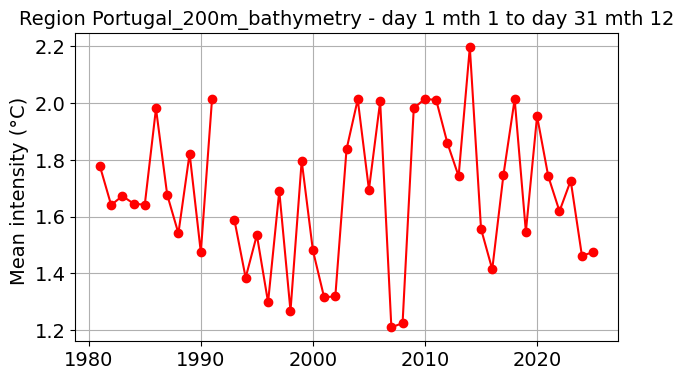

In [9]:
###############
   # Intensity
print("TIME PLOT - INTENSITY", (time.time() - start_time_script)/60)
mhw_meanintensity_per_year = (
    mhw_meanintensity_filtered
    .where(mhw_meanintensity_filtered != 0)   # mask out zeros
    .groupby('time.year')
    .mean(dim='time', skipna=True)   # compute mean ignoring NaN (and zeros now masked)
    .mean(dim=('lon', 'lat'), skipna=True)
)

plt.figure(figsize=(7, 4))
plt.plot(year_range, mhw_meanintensity_per_year,  c = 'red', marker='o')
plt.ylabel("Mean intensity (°C) ", fontsize=size_fonte)
plt.title(f"Region {region} - day {start_day} mth {start_mth} to day {end_day} mth {end_mth}", fontsize=size_fonte)
plt.xticks(fontsize=size_fonte)
plt.yticks(fontsize=size_fonte)
plt.grid(True)
plt.show()

   year  duration          start_time            end_time          area  \
0  1981         5  375926400000000000  376358400000000000  3.202321e+07   
1  1983         6  416188800000000000  416707200000000000  3.202321e+07   
2  1983         5  438912000000000000  439344000000000000  3.202321e+07   
3  1987         5  541987200000000000  542419200000000000  3.202321e+07   
4  1987         6  552614400000000000  553132800000000000  3.202321e+07   

      lat      lon  
0  36.875  351.125  
1  36.875  351.125  
2  36.875  351.125  
3  36.875  351.125  
4  36.875  351.125  
TIME PLOT - NUMBER EVENTS 0.14076433181762696


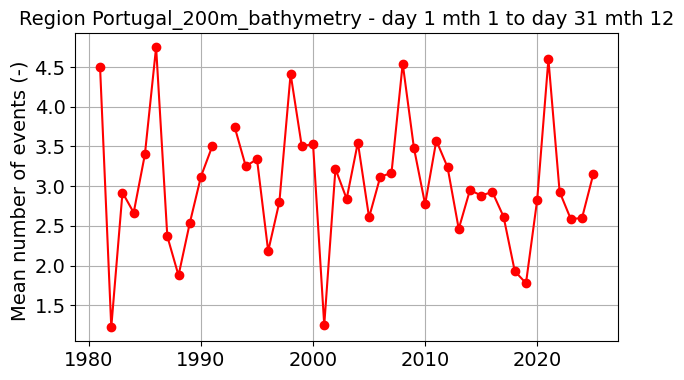

In [10]:
###################
# MHW feaures
events_count = xr.DataArray(
    np.zeros((len(mhw_meanintensity_filtered.time), len(mhw_meanintensity_filtered.lat), len(mhw_meanintensity_filtered.lon))),
    dims=('time', 'lat', 'lon'),
    coords={'time': mhw_meanintensity_filtered.time, 'lat': mhw_meanintensity_filtered.lat, 'lon': mhw_meanintensity_filtered.lon}
)

event_records  = []

# Iterate over each grid cell
for i in range(len(mhw_meanintensity_filtered.lat)):
    for j in range(len(mhw_meanintensity_filtered.lon)):
        # Extract the time series for the current grid cell
        intensity_series = mhw_meanintensity_filtered.isel(lat=i, lon=j)
        #print("intensity_series",intensity_series)
        # Identify where the intensity is greater than 0
        mhw_events = (intensity_series > 0).astype(int)
        #print("mhw_events",mhw_events)
        # Find the changes in the event status (start or end of an event)
        event_changes = np.diff(mhw_events, prepend=0)
        # Find the indices where events start and end          
        event_starts = np.where(event_changes == 1)[0]
        event_ends   = np.where(event_changes == -1)[0]                  
        #print("mhw_events",mhw_events)
        # Ensure that the number of starts and ends match
        if len(event_starts) > len(event_ends):
            event_ends = np.append(event_ends, len(mhw_events) - 1)
        # Count the number of events (each event start is marked by a positive change)
        events_count[:, i, j] = event_changes    
        for start, end in zip(event_starts, event_ends):
            start_time = mhw_meanintensity_filtered.time.isel(time=start).item()
            end_time = mhw_meanintensity_filtered.time.isel(time=end).item()
            duration = end - start
            area_cell = float(cell_area.isel(lat=i, lon=j).values)
            year      = pd.Timestamp(start_time).year
            event_records.append({
                "year": year,
                "duration": duration,
                "start_time": start_time,
                "end_time": end_time,
                "area": area_cell,
                "lat": mhw_meanintensity_filtered.lat.isel(lat=i).item(),
                "lon": mhw_meanintensity_filtered.lon.isel(lon=j).item()
            })    
            
event_df = pd.DataFrame(event_records)
print(event_df.head())

### number of event
print("TIME PLOT - NUMBER EVENTS", (time.time() - start_time_script)/60)
total_events = (events_count == 1).sum(dim=('lat', 'lon'))
events_per_year = (
    total_events
    .where(total_events != 0)   # mask out zeros
    .groupby('time.year')
    .mean(dim='time', skipna=True)   # compute mean ignoring NaN (and zeros now masked)
)

plt.figure(figsize=(7, 4))
plt.plot(year_range, events_per_year,  c = 'red', marker='o')
plt.ylabel("Mean number of events (-) ", fontsize=size_fonte) # over the area
plt.title(f"Region {region} - day {start_day} mth {start_mth} to day {end_day} mth {end_mth}", fontsize=size_fonte)
plt.xticks(fontsize=size_fonte)
plt.yticks(fontsize=size_fonte)
plt.grid(True)
plt.show()

/var/folders/wq/98_by44j0113pwx7jtjgd74w0000gn/T/ipykernel_9610/260449437.py:29: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.15)


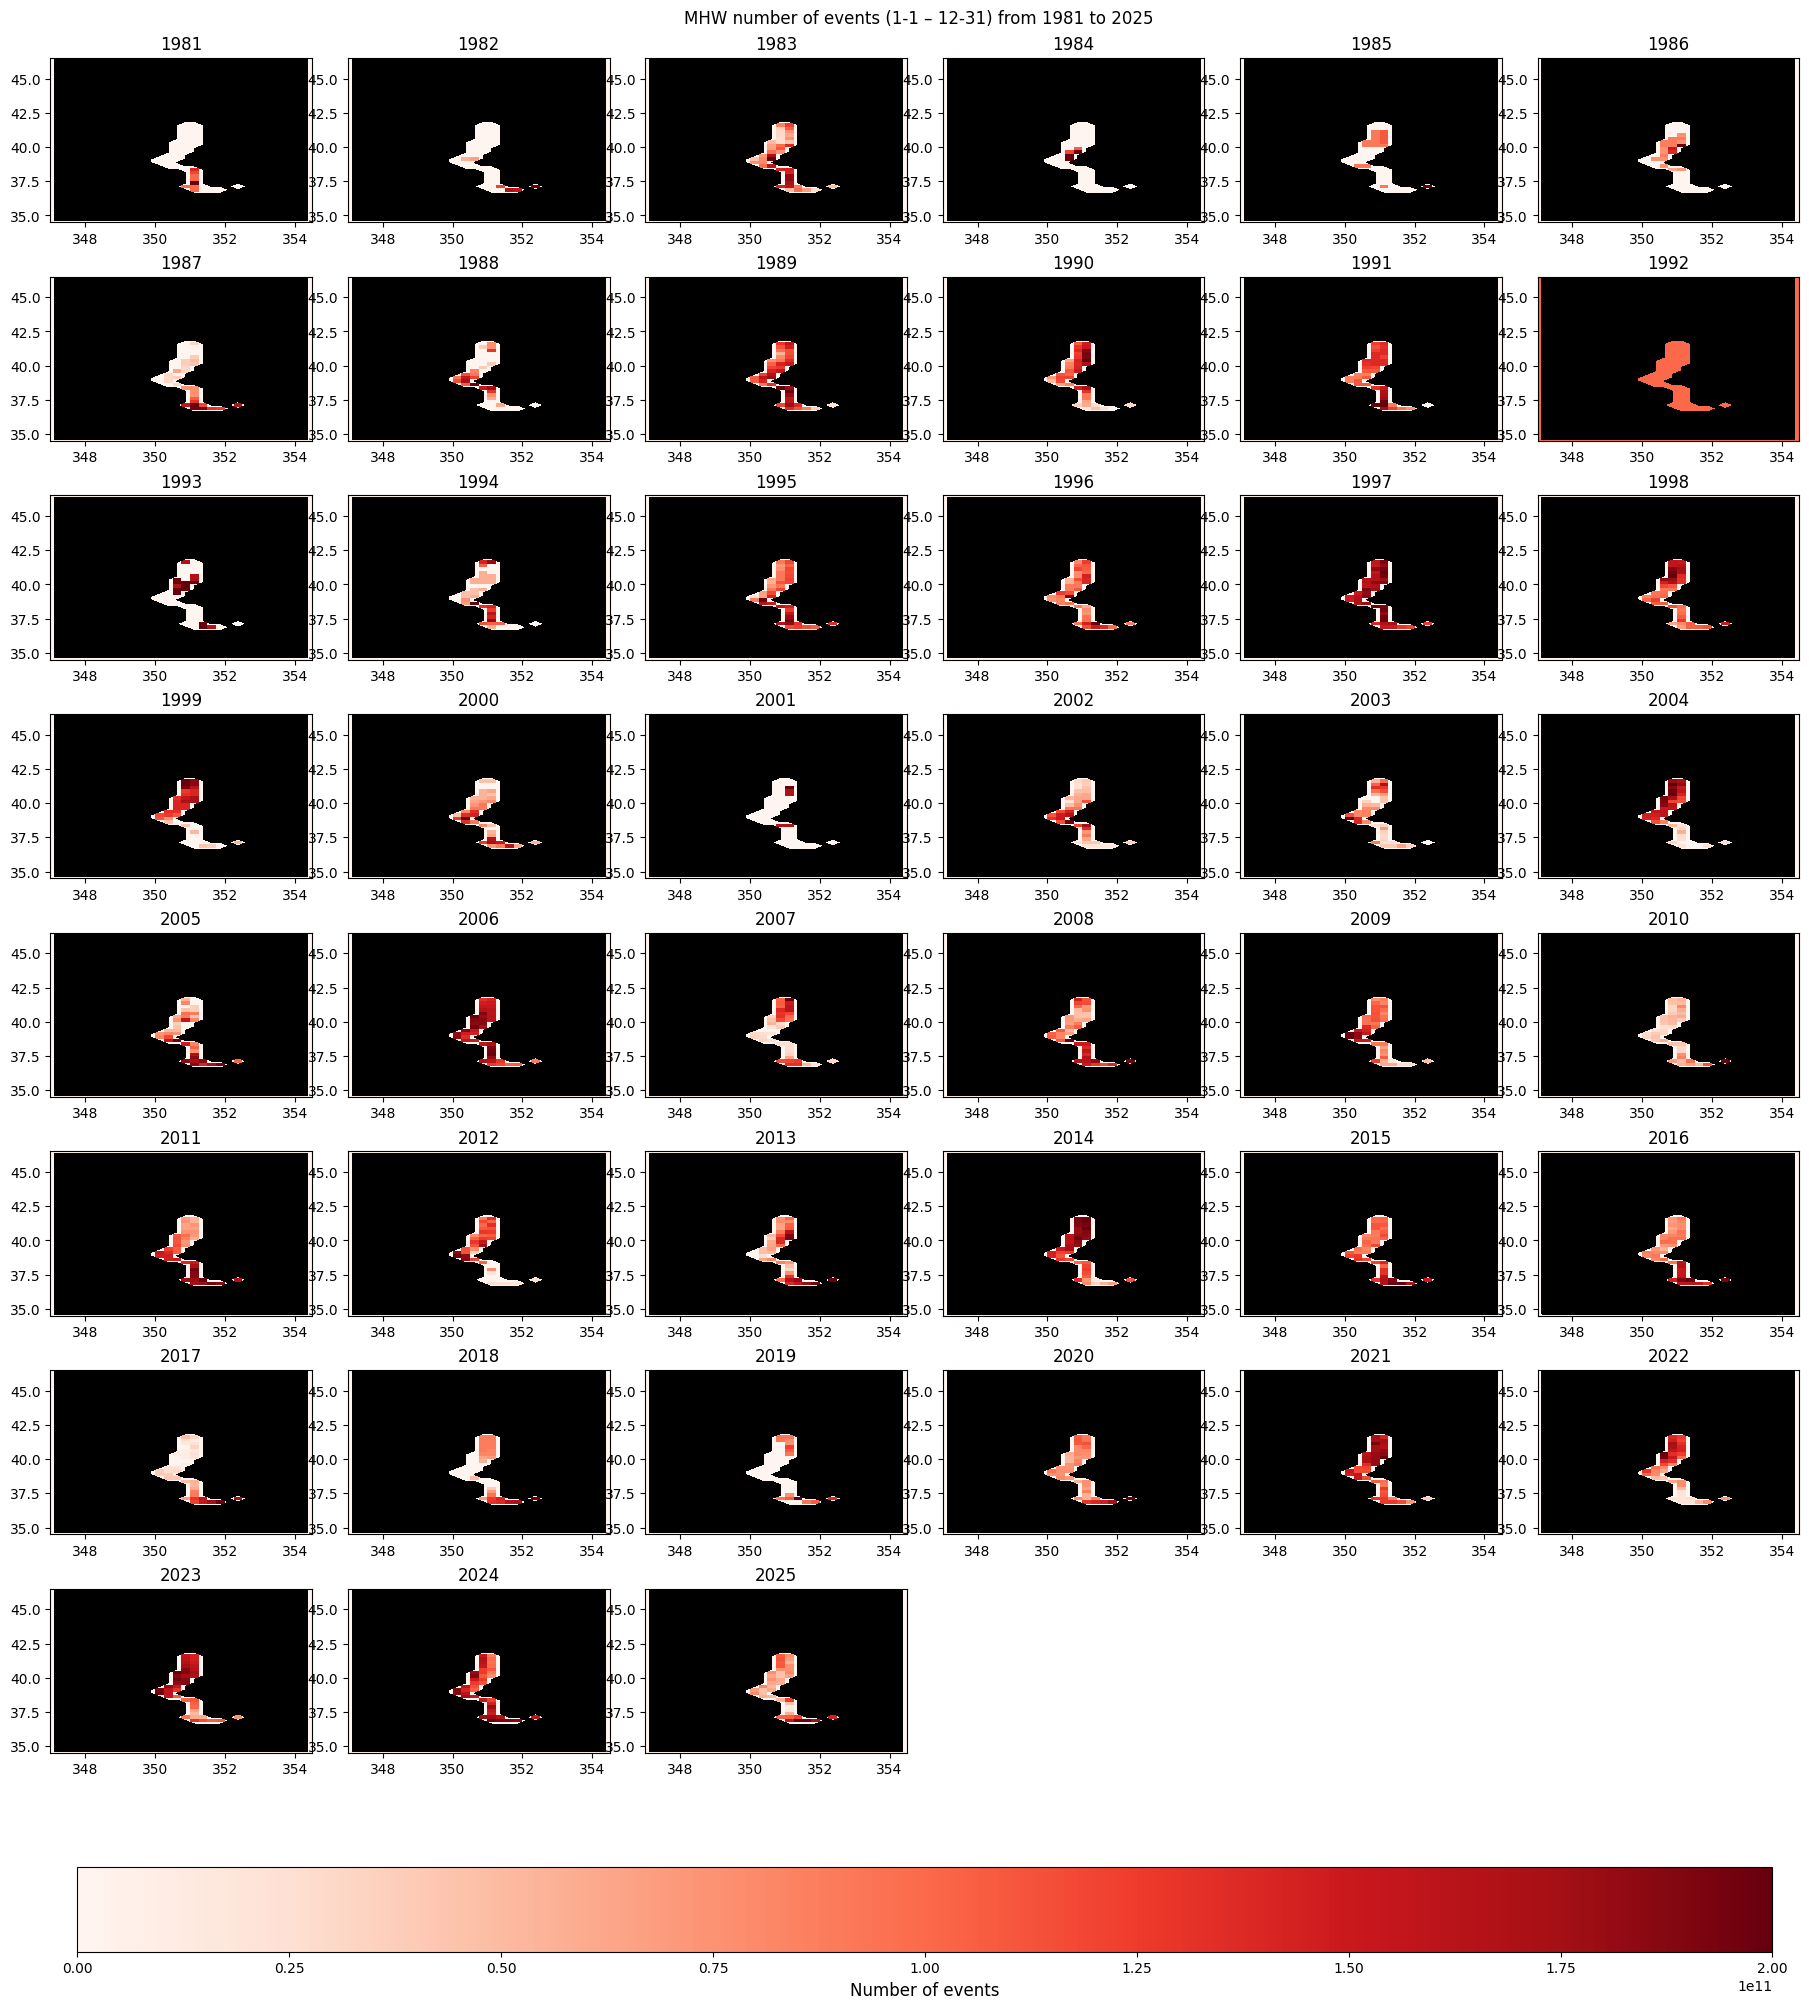

In [11]:
import matplotlib as mpl
# map activity for all years
min_value_leg=0
max_value_leg=2e11
n_years = yearend - yearbeg +1 
years = range(yearbeg, yearend + 1)
ncols = 6
nrows = math.ceil(n_years / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*2.5), constrained_layout=True)
axes = axes.flatten()  # Flatten in case it's 2D array
for i, year in enumerate(years):
   startdate = f'{year}-{start_mth}-{start_day}'
   if start_mth <= end_mth:
      enddate = f'{year}-{end_mth}-{end_day}'
   else:
      enddate = f'{year+1}-{end_mth}-{end_day}'       
   nb_events_plot =(mhw_meanintensity_filtered > 0).sel(time=slice(startdate, enddate)).sum(dim='time')
   ax = axes[i]
   nb_events_plot.plot(ax=ax, cmap='Reds', add_colorbar=False) #,vmin=min_value_leg, vmax=max_value_leg
   mask.where(mask == 0).plot.contourf(ax=ax, colors='k', add_colorbar=False)
   ax.set_title(f'{year}', fontsize=12)
   ax.set_xlabel('')
   ax.set_ylabel('')
# Hide unused subplots if any
for j in range(i + 1, len(axes)):
   axes[j].axis('off')
# Add a global colorbar
fig.subplots_adjust(bottom=0.15)
norm = mpl.colors.Normalize(vmin=min_value_leg, vmax=max_value_leg)
sm = mpl.cm.ScalarMappable(cmap='Reds', norm=norm)
sm.set_array([])

# Attach colorbar to all axes (horizontal, below)
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.05, pad=0.05)
cbar.set_label('Number of events', fontsize=12)
# Save figure
fig.suptitle(f'MHW number of events ({start_mth}-{start_day} – {end_mth}-{end_day}) from {yearbeg} to {yearend}', fontsize=12)
plt.show()

TIME PLOT - DURATION 0.17525944709777833


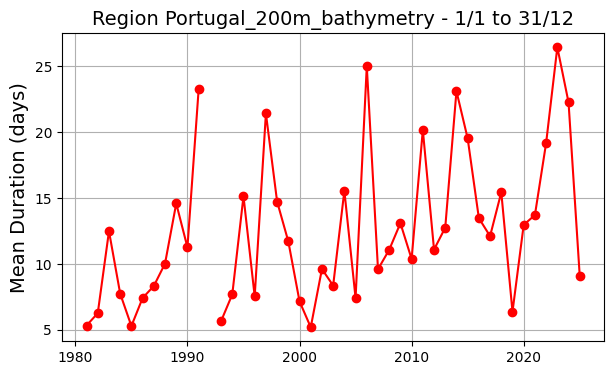

In [12]:
### duration
print("TIME PLOT - DURATION", (time.time() - start_time_script)/60)
durations_per_year_mean = (
    event_df.groupby("year")["duration"]
    .mean()
    .reindex(year_range, fill_value=np.nan)
)
durations_per_year_sum = (
    event_df.groupby("year")["duration"]
    .sum()
    .reindex(year_range, fill_value=np.nan)
)

## time series duration
plt.figure(figsize=(7, 4))
plt.plot(durations_per_year_mean.index,durations_per_year_mean.values, c='red', marker='o') #durations_per_year.index, 
plt.ylabel("Mean Duration (days)", fontsize=size_fonte) 
plt.title(f"Region {region} - {start_day}/{start_mth} to {end_day}/{end_mth}", fontsize=size_fonte)
plt.grid(True)
plt.show()

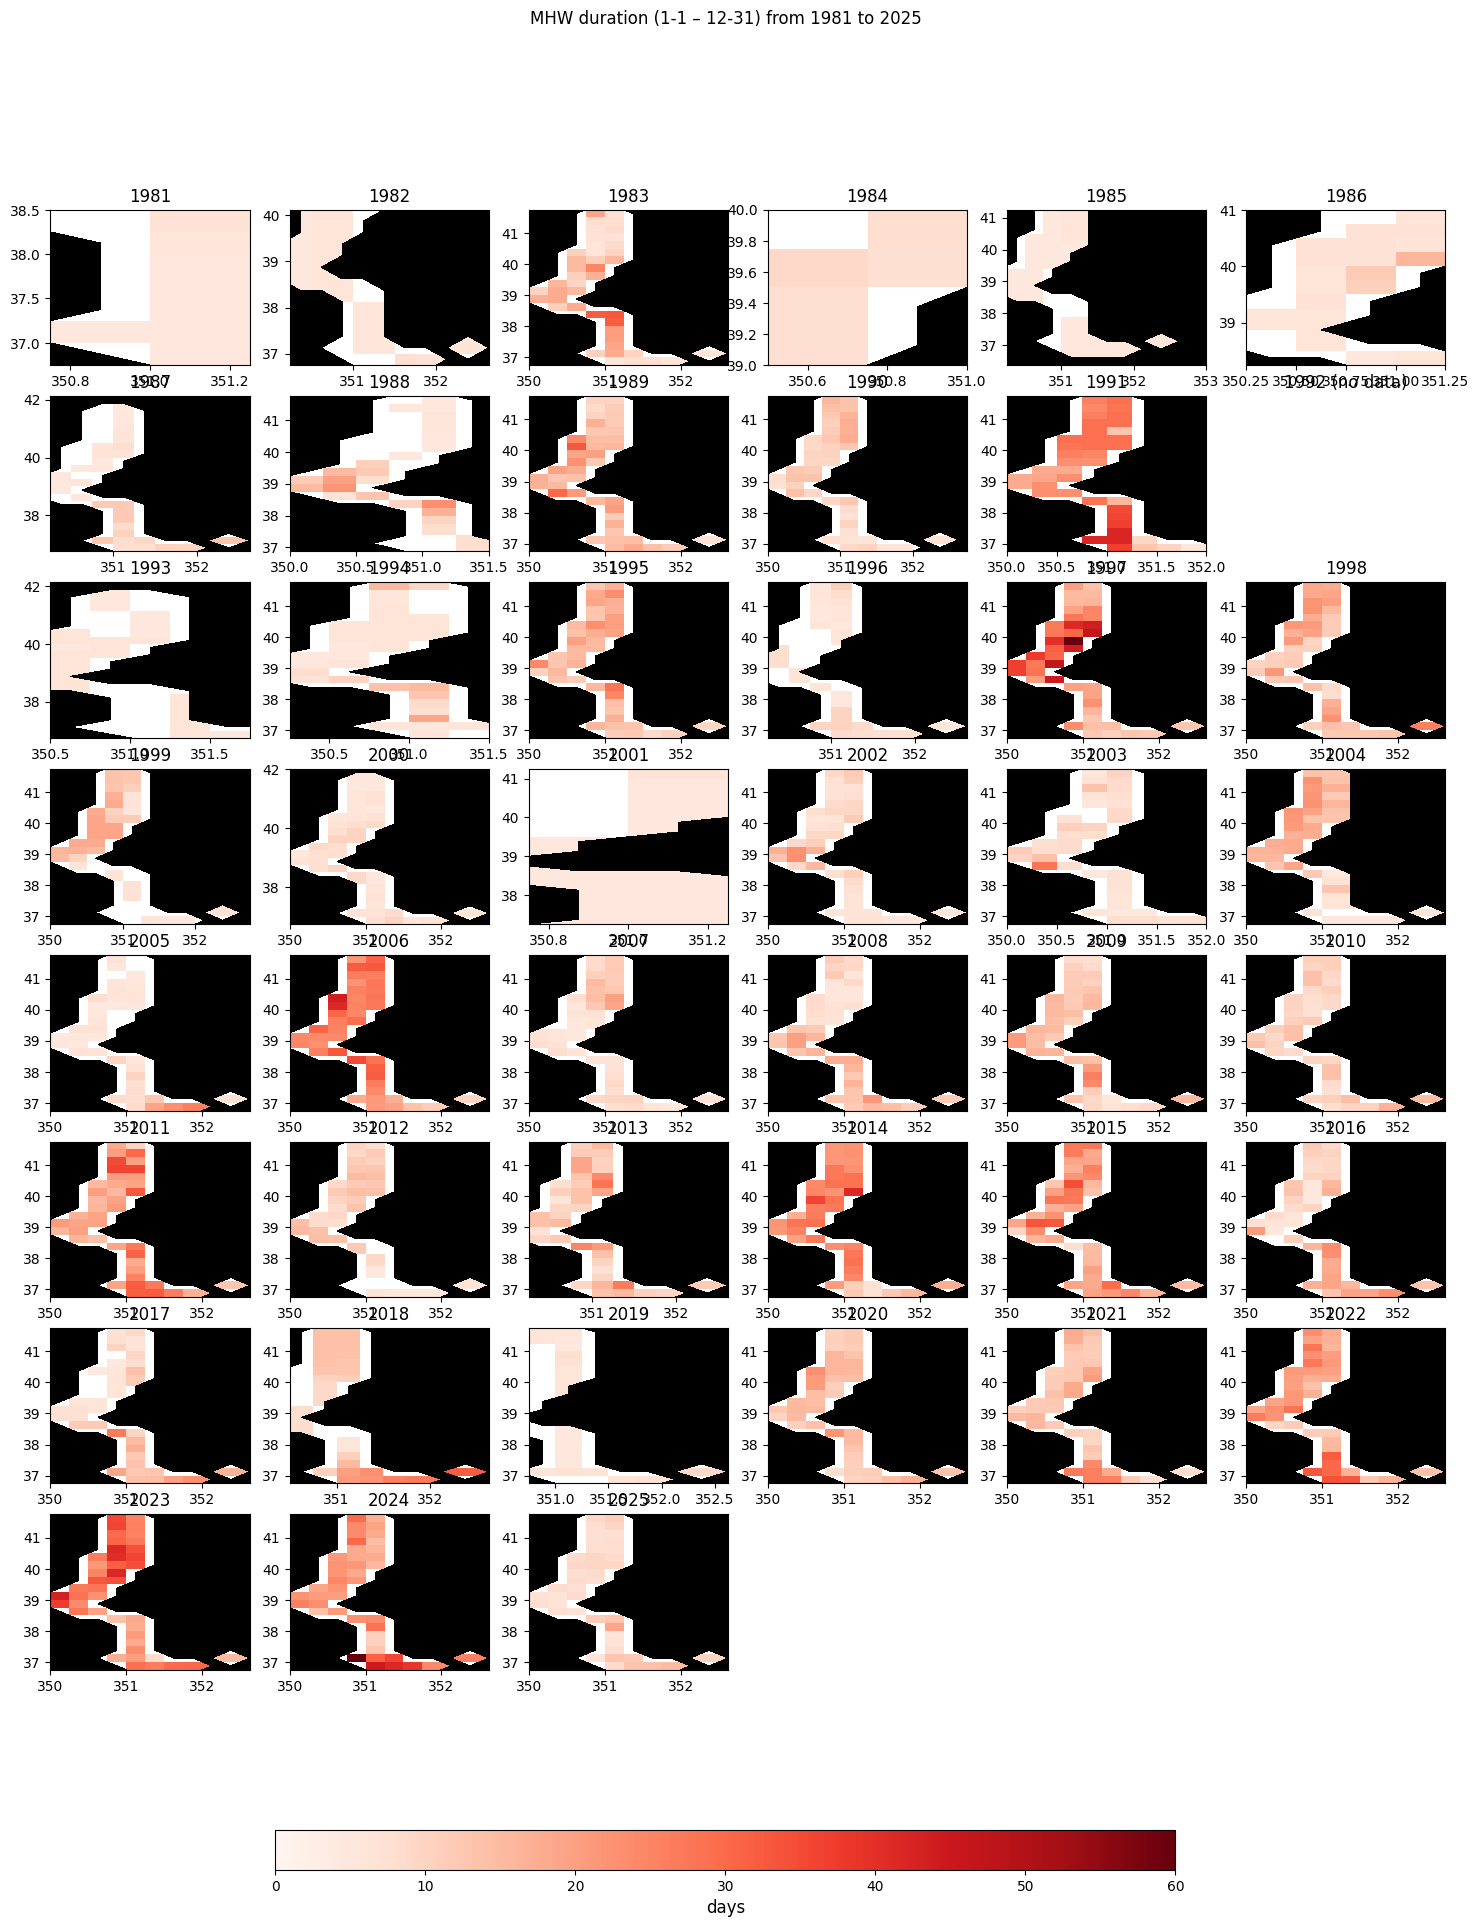

In [13]:
## map duration for all years
min_value_leg = 0
max_value_leg = 60
n_years = yearend - yearbeg + 1
years = range(yearbeg, yearend + 1)
ncols = 6
nrows = math.ceil(n_years / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*2.5))   # NO constrained_layout
axes = axes.flatten()
im = None
for i, year in enumerate(years):
    startdate = f'{year}-{start_mth}-{start_day}'
    if start_mth <= end_mth:
        enddate = f'{year}-{end_mth}-{end_day}'
    else:
        enddate = f'{year+1}-{end_mth}-{end_day}'
    ax = axes[i]
    duration_2d = (
        event_df[event_df["year"] == year]
        .groupby(["lat", "lon"])["duration"]
        .mean()
        .unstack(level="lon")
    )
    if duration_2d.empty or duration_2d.isna().all().all():
        ax.set_title(f'{year} (no data)', fontsize=12)
        ax.axis('off')
        continue
    da = xr.DataArray(
        duration_2d.values,
        dims=("lat", "lon"),
        coords={"lat": duration_2d.index, "lon": duration_2d.columns}
    )
    im = da.plot(ax=ax, cmap='Reds', vmin=min_value_leg, vmax=max_value_leg, add_colorbar=False)
    mask.where(mask == 0).plot.contourf(ax=ax, colors='k', add_colorbar=False)
    ax.set_title(f'{year}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'MHW duration ({start_mth}-{start_day} – {end_mth}-{end_day}) from {yearbeg} to {yearend}', fontsize=12)
fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.02])
if im is not None:
    fig.colorbar(im, cax=cbar_ax, orientation='horizontal')             # im owns the norm, no ghost axes
    cbar_ax.set_xlabel('days', fontsize=12)
plt.show()

TIME PLOT - AREA 0.19110080003738403


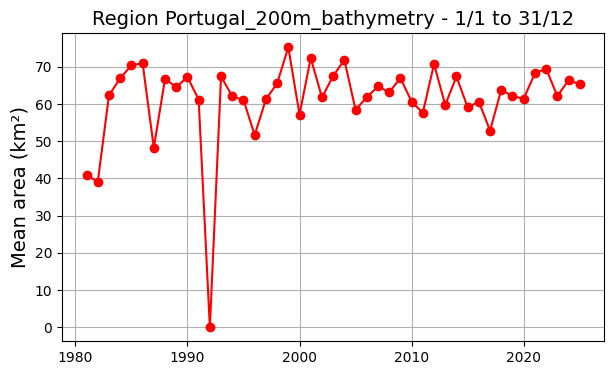

In [14]:
### area
print("TIME PLOT - AREA", (time.time() - start_time_script)/60)
area_per_year_mean = (
      event_df.groupby("year")["area"]
      .mean()
      .reindex(year_range, fill_value=0)
   ) 

area_per_year_sum = (
      event_df.groupby("year")["area"]
      .sum()
      .reindex(year_range, fill_value=0)
   ) 
   
## time series area
plt.figure(figsize=(7, 4))
plt.plot(area_per_year_mean.index,area_per_year_mean.values/ 1e6, c='red', marker='o') #durations_per_year.index, 
plt.ylabel("Mean area (km²)", fontsize=size_fonte) 
plt.title(f"Region {region} - {start_day}/{start_mth} to {end_day}/{end_mth}", fontsize=size_fonte)
plt.grid(True)
plt.show()

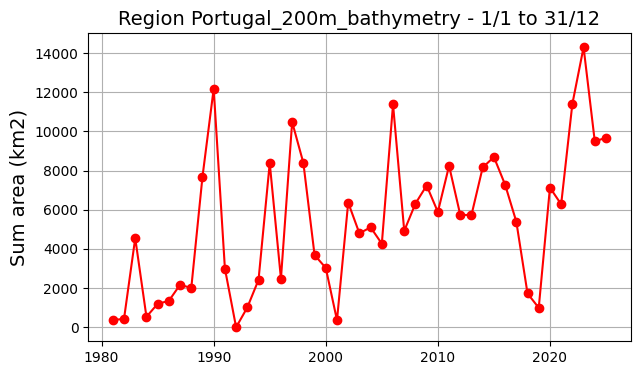

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(area_per_year_sum.index,area_per_year_sum.values/ 1e6, c='red', marker='o') #durations_per_year.index, 
plt.ylabel("Sum area (km2)", fontsize=size_fonte)
plt.title(f"Region {region} - {start_day}/{start_mth} to {end_day}/{end_mth}", fontsize=size_fonte)
plt.grid(True)
plt.show()

/var/folders/wq/98_by44j0113pwx7jtjgd74w0000gn/T/ipykernel_9610/3512920163.py:42: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.15)


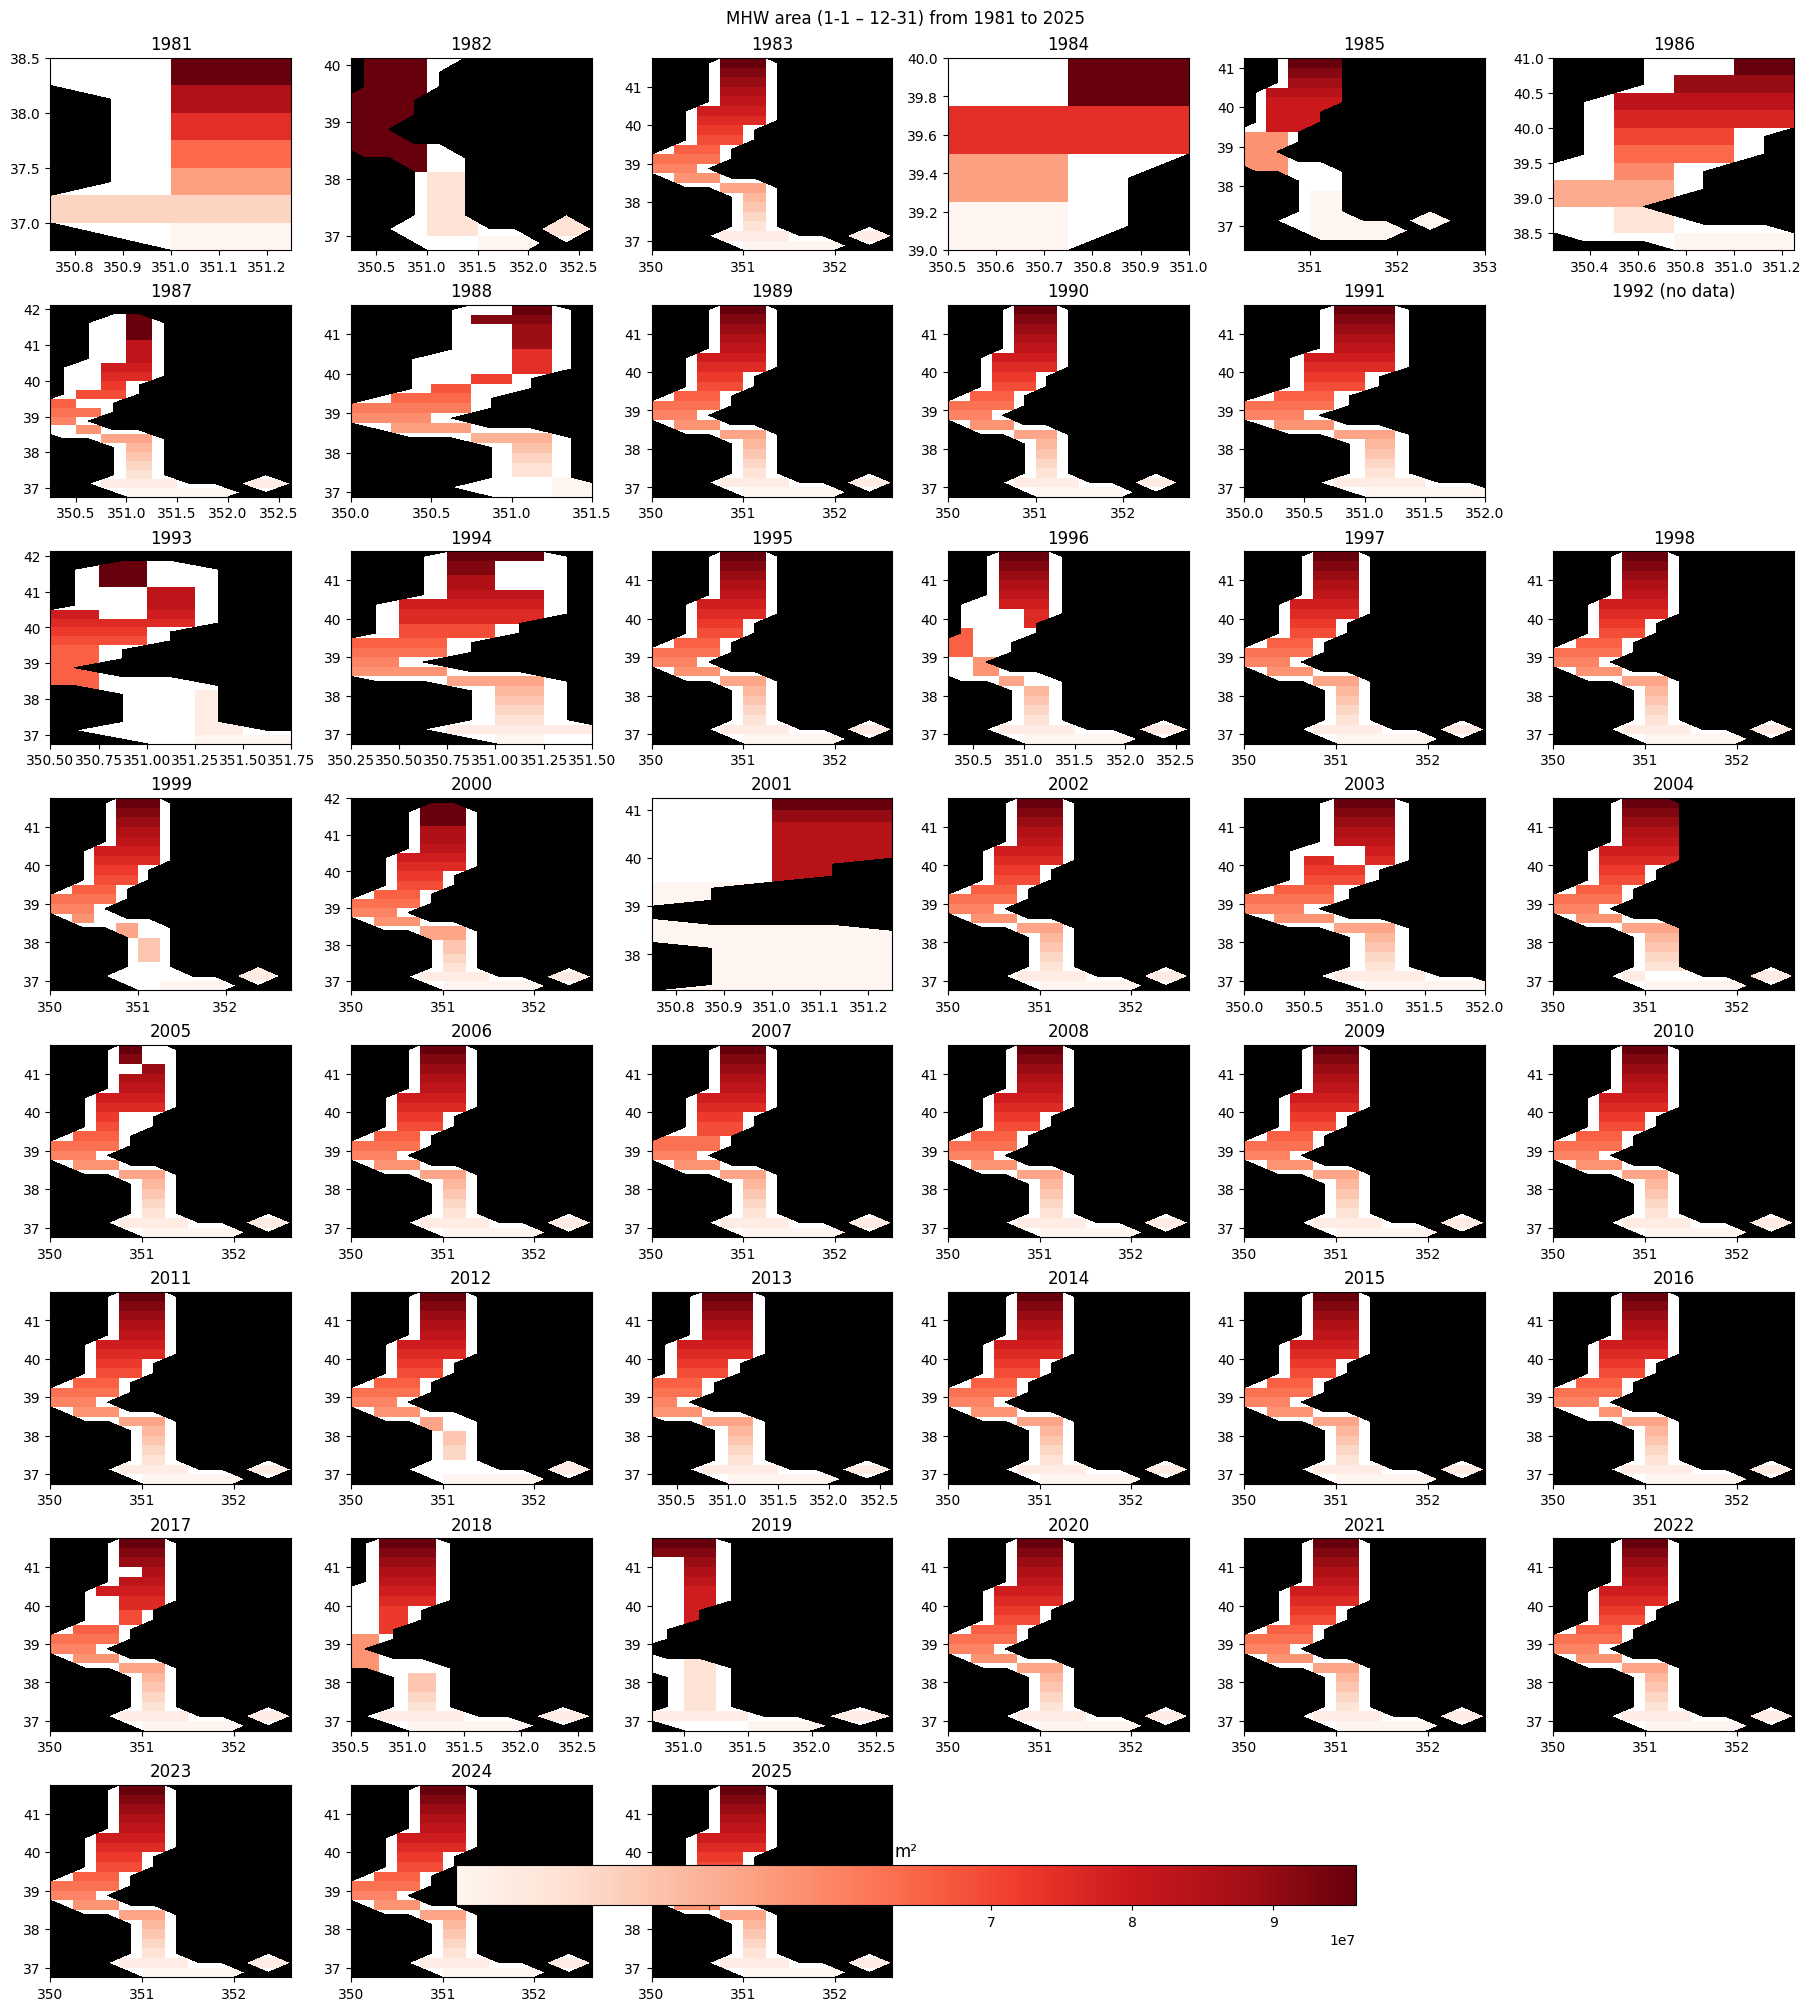

In [16]:
## map area for all years
   #min_value_leg=0
   #max_value_leg=2e11

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*2.5), constrained_layout=True)
axes = axes.flatten()  # Flatten in case it's 2D array
for i, year in enumerate(years):
    startdate = f'{year}-{start_mth}-{start_day}'
    if start_mth <= end_mth:
        enddate = f'{year}-{end_mth}-{end_day}'
    else:
        enddate = f'{year+1}-{end_mth}-{end_day}'       
    ax = axes[i]
    area_2d = (
        event_df[event_df["year"] == year]
        .groupby(["lat", "lon"])["area"]
        .mean()
        .unstack(level="lon")
    )
    if area_2d.empty or area_2d.isna().all().all():
        ax.set_title(f'{year} (no data)', fontsize=12)
        ax.axis('off')
        continue
    # Convert to xarray DataArray
    da = xr.DataArray(
        area_2d.values,
        dims=("lat", "lon"),
        coords={
            "lat": area_2d.index,
            "lon": area_2d.columns
        }
    )
    da.plot(ax=ax, cmap='Reds', add_colorbar=False)
    mask.where(mask == 0).plot.contourf(ax=ax, colors='k', add_colorbar=False)
    ax.set_title(f'{year}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
# Add a global colorbar
fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.02])  # [left, bottom, width, height]
da.plot(cmap='Reds', add_colorbar=True, cbar_ax=cbar_ax, cbar_kwargs={'orientation': 'horizontal'}) # , vmin=min_value_leg,    vmax=max_value_leg
cbar_ax.set_title('m²', fontsize=12)
cbar_ax.set_xlabel('')
cbar_ax.set_ylabel('')

# Save figure
fig.suptitle(f'MHW area ({start_mth}-{start_day} – {end_mth}-{end_day}) from {yearbeg} to {yearend}', fontsize=12)
plt.show()


TIME PLOT - ACTIVITY 0.21705946524937947


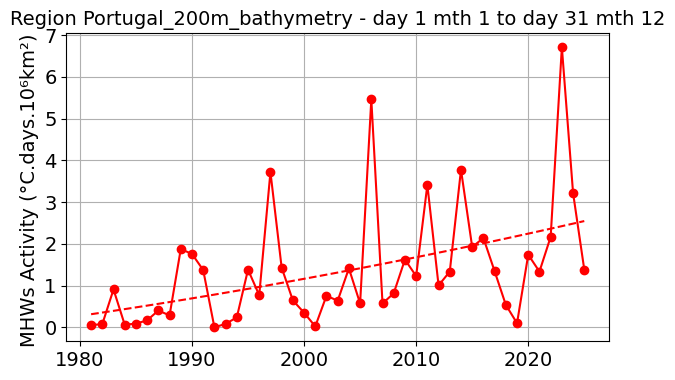

In [17]:
### activity
print("TIME PLOT - ACTIVITY", (time.time() - start_time_script)/60)
mhw_meanintensity_weighted= mhw_meanintensity_filtered * cell_area
activity_sum_per_year = mhw_meanintensity_weighted.groupby('time.year').sum(dim='time')
# Then, sum over the 'lon' and 'lat' dimensions to get a single value per year
total_activity = activity_sum_per_year.sum(dim=['lon', 'lat'])

## time series activity
model_1=np.polyfit(year_range,total_activity,2)
predict_1 = np.poly1d(model_1)
y_lin_reg_1 = predict_1(year_range)

plt.figure(figsize=(7, 4))
plt.plot(year_range,y_lin_reg_1/10**(12), c = 'red', linestyle='--')
plt.plot(year_range, total_activity/10**(12),  c = 'red', marker='o')
plt.ylabel("MHWs Activity (°C.days.10⁶km²) ", fontsize=size_fonte)
plt.title(f"Region {region} - day {start_day} mth {start_mth} to day {end_day} mth {end_mth}", fontsize=size_fonte)
plt.xticks(fontsize=size_fonte)
plt.yticks(fontsize=size_fonte)
plt.grid(True)
plt.show()

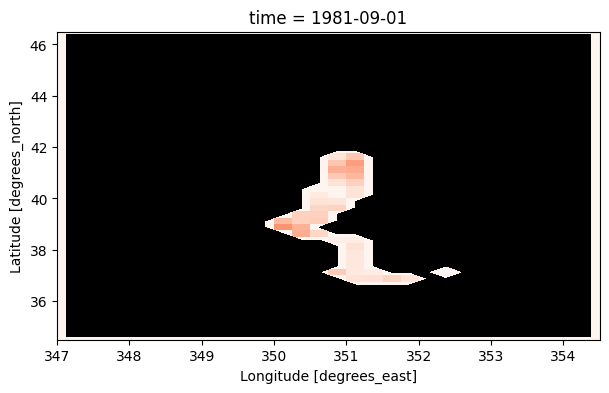

In [18]:
## map activity 
   #map activity for one specific year
min_value_leg=0
max_value_leg=10e10    
plt.figure(figsize=(7, 4))
startdate = f'2003-{start_mth}-{start_day}'
enddate = f'2003-{end_mth}-{end_day}'  
activity_a = mhw_meanintensity_filtered.sel(time=slice(startdate, enddate)).sum(dim='time') * cell_area
activity_a.plot(cmap='Reds', add_colorbar=False,vmin=min_value_leg, vmax=max_value_leg)
mask.where(mask == 0).plot.contourf(colors='k', add_colorbar=False)

plt.show()

/var/folders/wq/98_by44j0113pwx7jtjgd74w0000gn/T/ipykernel_9610/378752855.py:28: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.15)


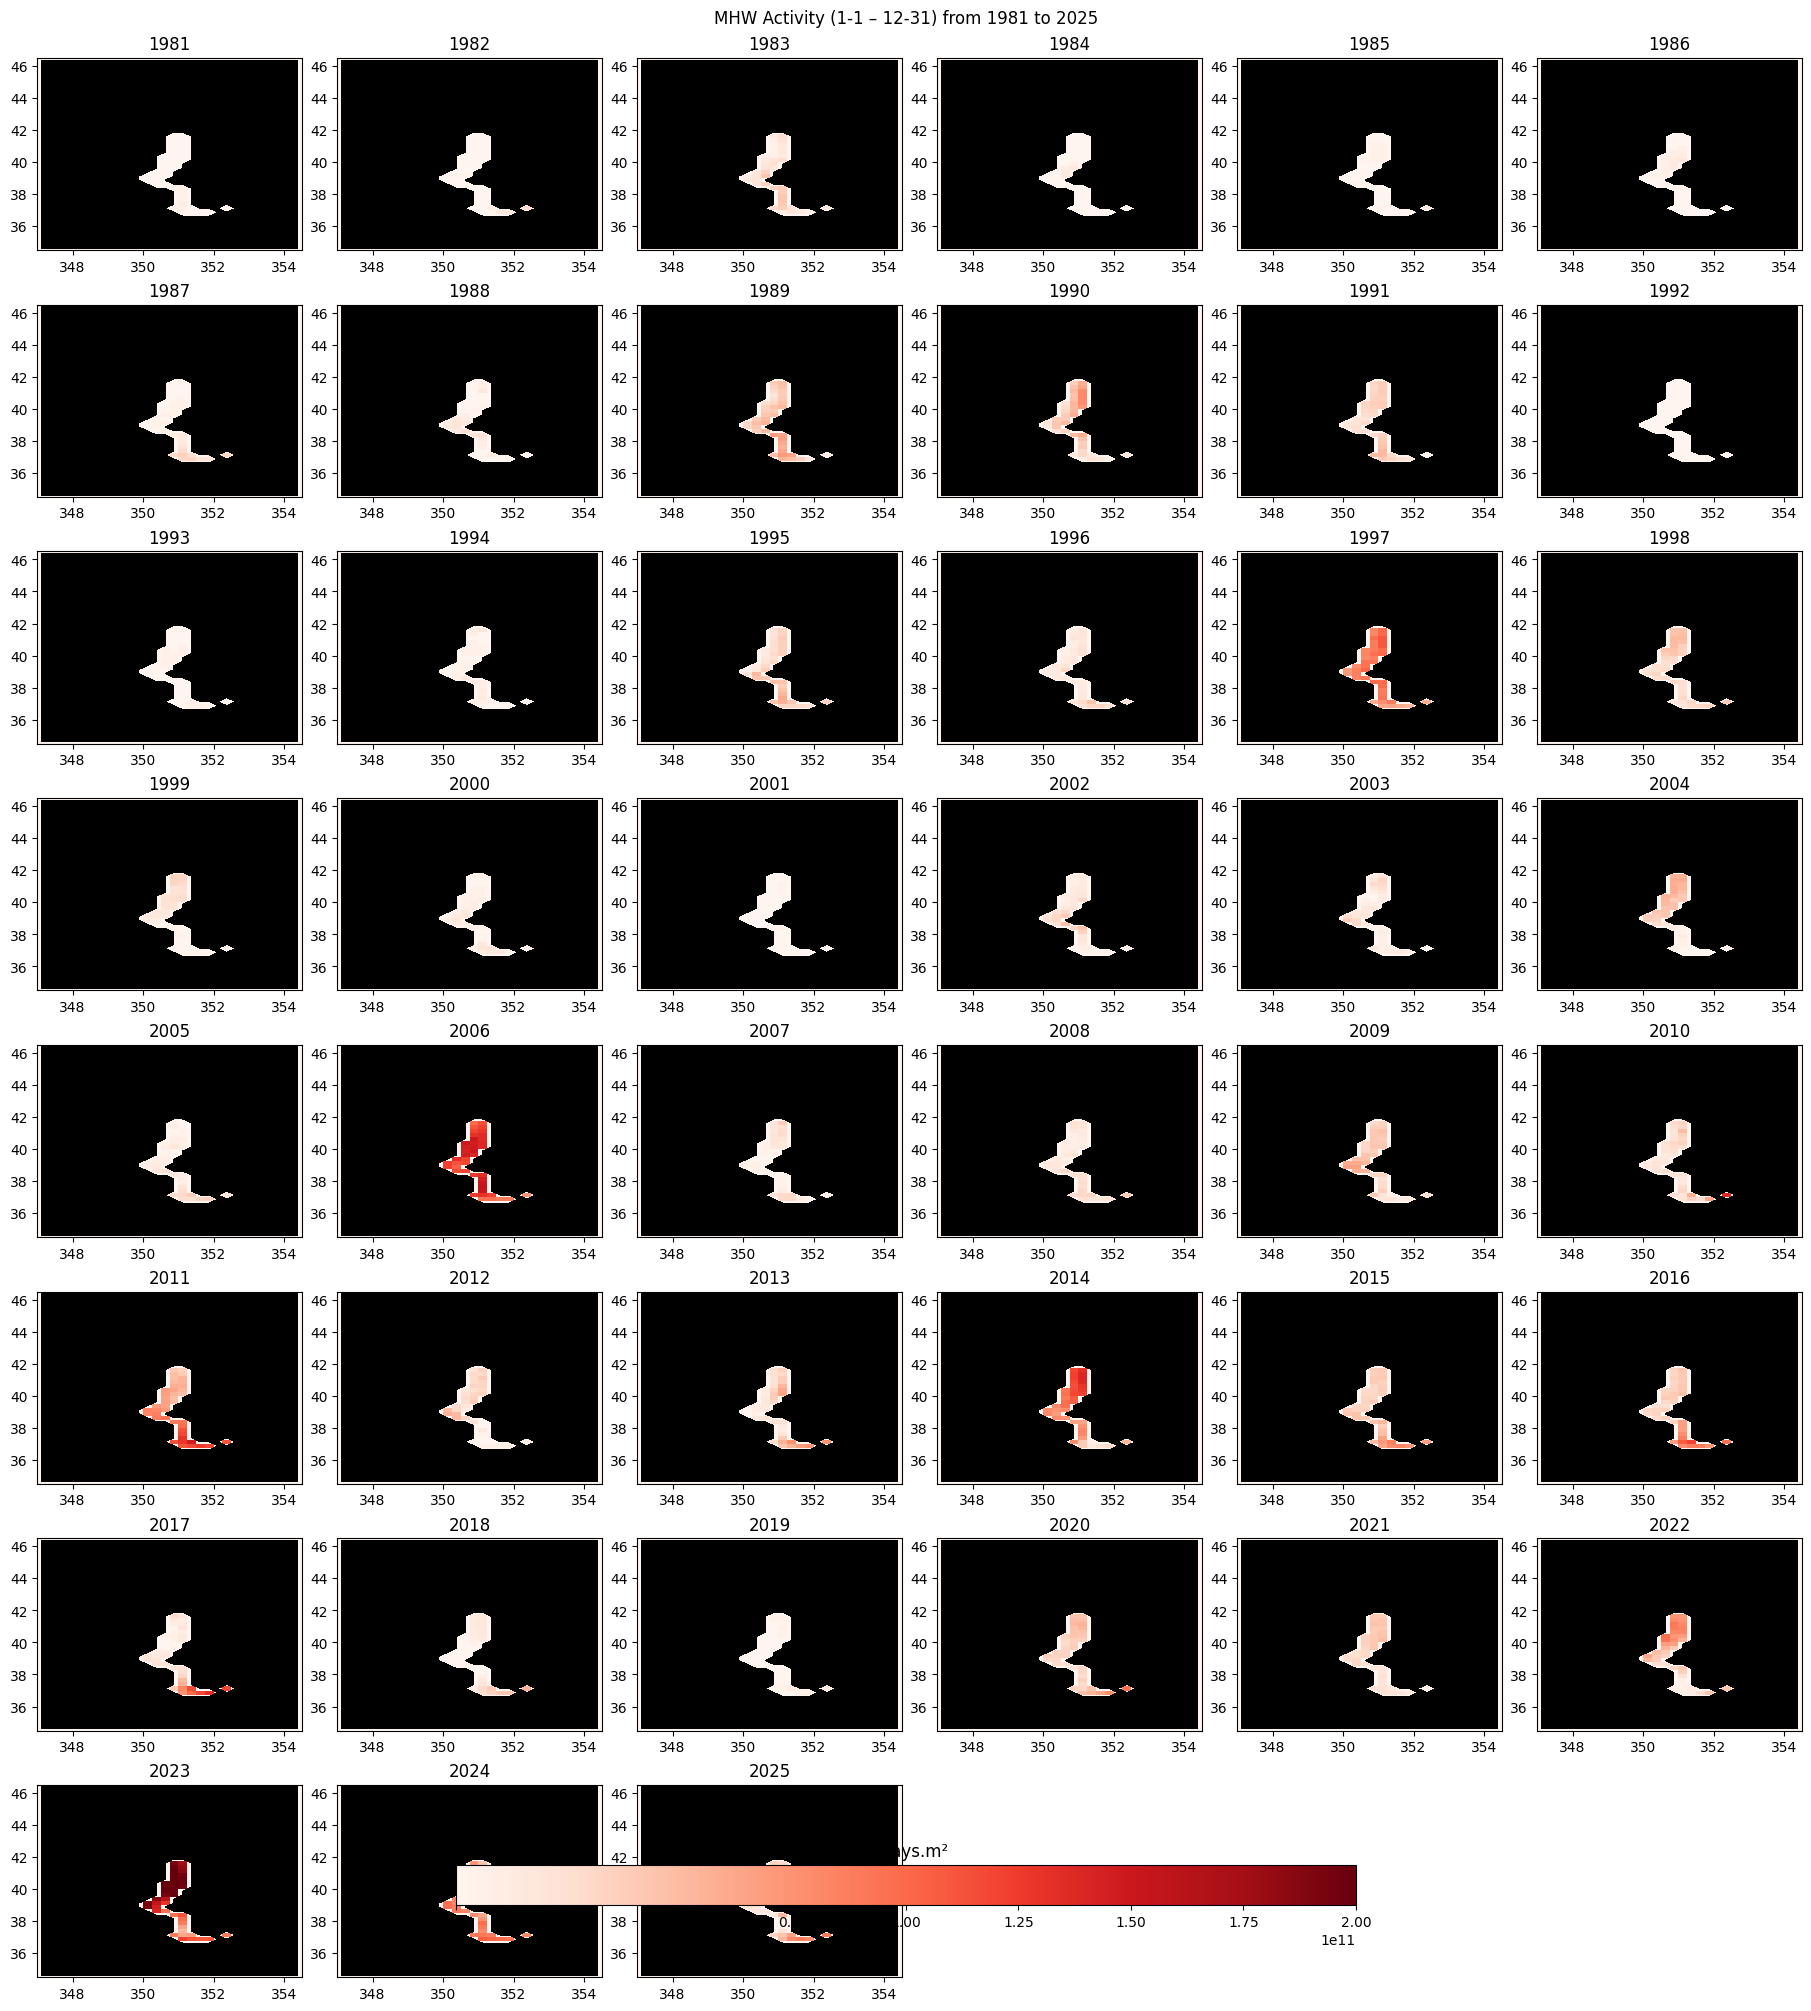

In [19]:
# map activity for all years
min_value_leg=0
max_value_leg=2e11
n_years = yearend - yearbeg +1 
years = range(yearbeg, yearend + 1)
ncols = 6
nrows = math.ceil(n_years / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*2.5), constrained_layout=True)
axes = axes.flatten()  # Flatten in case it's 2D array
for i, year in enumerate(years):
      startdate = f'{year}-{start_mth}-{start_day}'
      if start_mth <= end_mth:
         enddate = f'{year}-{end_mth}-{end_day}'
      else:
         enddate = f'{year+1}-{end_mth}-{end_day}'       
      activity_plot = mhw_meanintensity_filtered.sel(time=slice(startdate, enddate)).sum(dim='time') * cell_area
      ax = axes[i]
      activity_plot.plot(ax=ax, cmap='Reds', add_colorbar=False,vmin=min_value_leg, vmax=max_value_leg)
      mask.where(mask == 0).plot.contourf(ax=ax, colors='k', add_colorbar=False)
      ax.set_title(f'{year}', fontsize=12)
      ax.set_xlabel('')
      ax.set_ylabel('')
# Hide unused subplots if any
for j in range(i + 1, len(axes)):
      axes[j].axis('off')
# Add a global colorbar
fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.02])  # [left, bottom, width, height]
activity_plot.plot(cmap='Reds', add_colorbar=True, cbar_ax=cbar_ax, cbar_kwargs={'orientation': 'horizontal'}, vmin=min_value_leg,    vmax=max_value_leg) #
cbar_ax.set_title('C.days.m²', fontsize=12)
cbar_ax.set_xlabel('')
cbar_ax.set_ylabel('')
fig.suptitle(f'MHW Activity ({start_mth}-{start_day} – {end_mth}-{end_day}) from {yearbeg} to {yearend}', fontsize=12)
plt.show()

# End

In [20]:
duration_script = time.time() - start_time_script
print(f"Script executed in {int(duration_script / 60)} minutes or {int(duration_script / 3600)} hours.")


Script executed in 0 minutes or 0 hours.
